# Import statements

In [1]:
import sys
sys.path.append("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork")

from IPython.display import display, HTML, Markdown
import murraylab_tools.echo as mt_echo
import os.path
import pandas as pd
from murraylab_tools.echo.echo_functions import echo_round
import os.path
import math

import matplotlib.pyplot as plt

import os

import numpy as np


In [2]:
# get the working directory
os.getcwd()

'/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/examples/20250801_ID_384'

In [6]:
INPUT_DIR = os.path.join(os.getcwd(), "inputs")

OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")

# create the output directory if it does not exist
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

if not os.path.exists(INPUT_DIR):
    os.makedirs(INPUT_DIR)

# Input Spreadsheet

In [15]:
# Read the CSV file
df = pd.read_csv(os.path.join(INPUT_DIR, "ID_96w_transfections_Aug_22_2025.csv"), skiprows=1)
# Define the columns to use
columns_to_use = [
    'plasmid concentration nM', '1.1', '2.1', '3.1', '4.1', '5.1', '6.1', '7.1', '8.1', '9.1', '10.1', '11.1', '12.1', '13.1', '14.1',
    '15.1', '16.1', '17.1', '18.1', '19.1', '20.1', '21.1', '22.1', '23.1', '24.1', '25.1', '26.1', '27.1', '28.1', '29.1', '30.1', '31.1',
    '32.1', '33.1', '34.1', '35.1', '36.1', '37.1', '38.1', '39.1', '40.1', '41.1', '42.1', '43.1', '44.1', '45.1', '46.1', '47.1', '48.1', '49.1',
    '50.1', '51.1', '52.1', '53.1', '54.1', '55.1', '56.1', '57.1', '58.1', '59.1', '60.1', '61.1', '62.1', '63.1', '64.1', '65.1', '66.1', '67.1',
    '68.1', '69.1', '70.1', '71.1', '72.1', '73.1', '74.1', '75.1', '76.1', '77.1', '78.1', '79.1', '80.1', '81.1', '82.1', '83.1', '84.1', '85.1',
    '86.1', '87.1', '88.1', '89.1', '90.1', '91.1', '92.1', '93.1', '94.1', '95.1', '96.1',
]

# Filter the DataFrame to include only the specified columns
df = df[columns_to_use]

# Drop rows where 'plasmid concentration nM' is NaN and specific rows by index
df = df[~df["plasmid concentration nM"].isna()]

df = df.drop([0, 1, 12])


# Transpose the DataFrame and reverse the order of columns
df = df.transpose()
df = df[df.columns[::-1]]

# Rename columns based on the first row of the transposed DataFrame
df = df.rename(columns=df.iloc[0])
df = df.drop(index=['plasmid concentration nM'])

df.columns

df

# Rename specific columns to 'concentration(nM)'
df = df.rename(columns={'pUC19 (maxi)' : 'concentration(nM).1',
                        'm169_GvpW': 'concentration(nM).2', 
                        'm168_GvpV': 'concentration(nM).3',
                        'm167_GvpN': 'concentration(nM).4',
                        'm166_GvpK': 'concentration(nM).5',
                        'm165_GvpJ': 'concentration(nM).6',
                        'm164_GvpG': 'concentration(nM).7',
                        'm163_GvpF': 'concentration(nM).8',
                        'm162_GvpA': 'concentration(nM).9'})

# List of inserts to add as columns
inserts = ['water', 'puc19', 'm169', 'm168', 'm167', 'm166', 'm165', 'm164', 'm163', 'm162']
df
# Insert each component column into the DataFrame
for i, insert in enumerate(inserts, start=1):
    df.insert(i * 2 - 1, f'component_{i-1}', insert)

# Reset index and set 'well_id' as index
df = df.reset_index(drop=True).set_index('well_id')

# Drop unnecessary columns
df = df.drop(columns=['component_0', 'Final volume of DNA before water (uL)'])

# Save the DataFrame to a CSV file
df.to_csv(os.path.join(INPUT_DIR, 'ID_96w_association.csv'))


In [16]:
df

,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8,component_9,concentration(nM).9
well_id,,,,,,,,,,,,,,,,,,
H1,puc19,34.498,m169,0.199,m168,0.199,m167,0.199,m166,0.199,m165,0.199,m164,0.199,m163,0.795,m162,7.955
G1,puc19,34.578,m169,0.199,m168,0.199,m167,0.199,m166,0.199,m165,0.199,m164,0.795,m163,0.199,m162,7.955
F1,puc19,34.496,m169,0.199,m168,0.199,m167,0.199,m166,0.199,m165,0.795,m164,0.199,m163,0.199,m162,7.955
E1,puc19,34.558,m169,0.199,m168,0.199,m167,0.199,m166,0.795,m165,0.199,m164,0.199,m163,0.199,m162,7.955
D1,puc19,34.473,m169,0.199,m168,0.199,m167,0.795,m166,0.199,m165,0.199,m164,0.199,m163,0.199,m162,7.955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E12,puc19,28.979,m169,0.795,m168,0.795,m167,0.795,m166,0.199,m165,0.795,m164,0.795,m163,0.795,m162,7.955
D12,puc19,29.064,m169,0.795,m168,0.795,m167,0.199,m166,0.795,m165,0.795,m164,0.795,m163,0.795,m162,7.955
C12,puc19,28.954,m169,0.795,m168,0.199,m167,0.795,m166,0.795,m165,0.795,m164,0.795,m163,0.795,m162,7.955


# Clear source plate


In [17]:
import pandas as pd

df = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250819_nivin_first_run/inputs/source_plate.dat", delimiter=',', header=None)
df = df.iloc[0:0]
df.to_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250819_nivin_first_run/inputs/source_plate.dat", index=False, header=False)

# Output Spreadsheet

In [18]:
#relevent input and output files

stock_file = os.path.join(INPUT_DIR, "96w_echo_source_sheet_exact_wells.csv")
assoc_pre_file = os.path.join(INPUT_DIR, "ID_96w_association.csv")
assoc_name = os.path.join(os.path.join(OUTPUT_DIR, "ID_08192225_echo_picklist.csv"))
plate_file  = os.path.join(INPUT_DIR, "source_plate.dat") 

In [8]:
# make our materials and add them to a source plate using the SourcePlate objects and EchoSourceMaterial objects

# read in the source plate file
source_plate_df = pd.read_csv(stock_file)

#create a source well plate object
source_well_plate = mt_echo.SourcePlate(filename = plate_file, SPtype='384PP_AQ_BP', SPname="384_source_c1", reuse_wells=True)

# iterate over the source plate file rows and create materials. Then add those materials to a well in the source plate instance.
for index, row in source_plate_df.iterrows():
   source_well_plate.add_material_to_well(well=row.Location, material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units), volume=31000)
   print(row.Location)

# create the EchoRun experiment with our source plate instance.
assoc_echo_calculator = mt_echo.EchoRun(DPtype= "Axygen 96", plate=source_well_plate)

# make the materials in the experiment known
for index, row in source_plate_df.iterrows():
   assoc_echo_calculator.add_material(material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units))
   print(row.Name)
   if index == 8: # break out of for loop when one copy of materials in the source plate are defined for the experiment
      break


C1
A3
A5
A7
A9
A11
A13
A15
A24
E1
G1
I1
K1
M1
O1
C3
E3
G3
C5
E5
G5
I5
C7
E7
G7
C9
E9
G9
C11
E11
G11
I11
C13
E13
G13
B15
C15
D15
E15
F15
G15
H15
I15
J15
K15
L15
M15
N15
O15
P15
A17
B17
C17
D17
E17
A1
A2
A4
A6
A8
A10
A12
A14
A16
A18
A19
A20
A21
A22
A23
B1
B2
B3
B4
B5
B6
B7
B8
B9
B10
B11
B12
B13
B14
B16
B18
B19
B20
B21
B22
B23
B24
C2
C4
C6
C8
C10
C12
C14
C16
C18
C19
C20
C21
C22
C23
C24
D1
D2
D3
D4
D5
D6
D7
D8
D9
D10
D11
D12
D13
D14
D16
D18
D19
D20
D21
D22
D23
D24
E2
E4
E6
E8
E10
E12
E14
E16
E18
E19
E20
E21
E22
E23
E24
F1
F2
F3
F4
F5
10000
NN400_GvpA
NN458_GvpF
NN410_GvpG
NN457_GvpJ
wt_GvpK
NN449_GvpN
wt_GvpW
puc19
water


In [9]:
# # make our materials and add them to a source plate using the SourcePlate objects and EchoSourceMaterial objects
# # this doesn't make a source plate with stuff in it, so the experiment will tell you what wells to fill.

# # read in the source plate file
# source_plate_df = pd.read_csv(stock_file)

# #create a source well plate object
# source_well_plate = mt_echo.SourcePlate(filename = plate_file, SPtype='384PP_Plus_AQ_BP', SPname="384_source_c1", reuse_wells=True, volume=31000)

# # create the EchoRun experiment with our source plate instance.
# assoc_echo_calculator = mt_echo.EchoRun(DPtype= "Axygen 96", plate=source_well_plate)

# # make the materials in the experiment known
# for index, row in source_plate_df.iterrows():
#    assoc_echo_calculator.add_material(material = mt_echo.EchoSourceMaterial(name=row.Name, concentration=row.Concentration, length=row.Length, units=row.Units))
#    if index == 8: # break out of for loop when one copy of materials in the source plate are defined for the experiment
#       break

In [10]:
assoc_echo_calculator.rxn_vol = 15000.00 # PCR is large-volume!

# Define which column of the source file is what
name_col  = 1
conc_col  = 2
len_col   = 3
well_col  = 0
plate_col = 4

In [11]:
# Build a protocol, based on the association file.
assoc_echo_calculator.build_picklist_from_association_spreadsheet(input_filename= assoc_pre_file,
                                                                  well_column= 0,
                                                                  fill_with_water = True,
                                                                  water_name = "water"
                                                                  )


In [12]:
# Write the picklist
assoc_echo_calculator.write_picklist(assoc_name)

/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material wt_GvpW into well A1; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material NN449_GvpN into well A1; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material wt_GvpK into well A1; are you sure you want to do this?
  warnings.warn(f"Requesting 0 volume from material {self.name}"
/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/murraylab_tools/echo/echo_functions.py:184: UserWarning: Requesting 0 volume from material NN

# Trouble Shoot Section for Error that Says Negative Dimension Not Allowed.

This is because you have added more filled source wells than needed to the source plate. "Additional wells needed" then becomes negative

In [13]:
material_well_dict = {}
for mat_name in assoc_echo_calculator.material_dict:
    mat = assoc_echo_calculator.material_dict[mat_name]
    if mat:
        name, conc = mat.name, mat.concentration
        if mat.plate is None:
            raise Exception(f"Material '{mat}' doesn't have a plate " +\
                                "at plate initialization time.")
        print("Matieral name: " + mat.name)
        print("Material source concentration: " + str(mat.concentration))
        #print(mat.plate)
        echo_volume = mat.echo_volume_requested
        tot_available_vol = mat.plate.get_available_material(mat)
        volume_additional = echo_volume-tot_available_vol
        print("How much volue needed for run: " + str(echo_volume))
        n_source_wells = math.ceil(float(volume_additional) /  44000)
        print("Number of source wells needed additional: " + str(n_source_wells))
        print("Number of source wells needed: " + str(math.ceil(float(echo_volume) /  44000)))
        #wells_to_fill = mat.plate.request_source_wells(mat)
        
        

        # material_well_dict[(name, conc)] = wells_to_fill

        # if (name, conc) in mat.plate.materials_to_add:
        #     material_well_dict[(name, conc)] += \
        #                             mat.plate.materials_to_add[name, conc]

#assoc_echo_calculator.material_dict['m163'].concentration

Matieral name: NN400_GvpA
Material source concentration: 124.781
How much volue needed for run: 60200
Number of source wells needed additional: 2
Number of source wells needed: 2
Matieral name: NN458_GvpF
Material source concentration: 15.768
How much volue needed for run: 34675
Number of source wells needed additional: 1
Number of source wells needed: 1
Matieral name: NN410_GvpG
Material source concentration: 13.159
How much volue needed for run: 41875
Number of source wells needed additional: 1
Number of source wells needed: 1
Matieral name: NN457_GvpJ
Material source concentration: 16.21
How much volue needed for run: 32175
Number of source wells needed additional: 1
Number of source wells needed: 1
Matieral name: wt_GvpK
Material source concentration: 15.56
How much volue needed for run: 30800
Number of source wells needed additional: 1
Number of source wells needed: 1
Matieral name: NN449_GvpN
Material source concentration: 11.966
How much volue needed for run: 43650
Number of sou

# Checker

In [14]:
import pandas as pd

final_association = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250819_nivin_first_run/inputs/Nivin_96w_association.csv")
output_association = pd.read_csv("/resnick/groups/shapirolab/idev/packages/MurrayLabTools_IshaanFork/ishaan_runs/20250819_nivin_first_run/outputs/nivin_08192025_echo_picklist.csv_EchoInput.csv")


display(final_association.head())
display(output_association.head())

volume_final = 15000.00

,well_id,component_1,concentration(nM).1,component_2,concentration(nM).2,component_3,concentration(nM).3,component_4,concentration(nM).4,component_5,concentration(nM).5,component_6,concentration(nM).6,component_7,concentration(nM).7,component_8,concentration(nM).8
0,H1,puc19,22.765,wt_GvpW,0.146,NN449_GvpN,0.146,wt_GvpK,0.146,NN457_GvpJ,0.146,NN410_GvpG,0.146,NN458_GvpF,0.583,NN400_GvpA,5.833
1,G1,puc19,22.823,wt_GvpW,0.146,NN449_GvpN,0.146,wt_GvpK,0.146,NN457_GvpJ,0.146,NN410_GvpG,0.583,NN458_GvpF,0.146,NN400_GvpA,5.833
2,F1,puc19,22.835,wt_GvpW,0.146,NN449_GvpN,0.146,wt_GvpK,0.146,NN457_GvpJ,0.583,NN410_GvpG,0.146,NN458_GvpF,0.146,NN400_GvpA,5.833
3,E1,puc19,22.807,wt_GvpW,0.146,NN449_GvpN,0.146,wt_GvpK,0.583,NN457_GvpJ,0.146,NN410_GvpG,0.146,NN458_GvpF,0.146,NN400_GvpA,5.833
4,D1,puc19,22.761,wt_GvpW,0.146,NN449_GvpN,0.583,wt_GvpK,0.146,NN457_GvpJ,0.146,NN410_GvpG,0.146,NN458_GvpF,0.146,NN400_GvpA,5.833


,Source Plate,Source Plate Type,Source Well,Sample ID,Destination Plate Name,Destination Well,Transfer Volume,Sample Comment
0,384_source_c1,384PP_AQ_BP,C1,NN400_GvpA,Axygen 96,H1,700,Actual concentration: 5.82
1,384_source_c1,384PP_AQ_BP,C1,NN400_GvpA,Axygen 96,G1,700,Actual concentration: 5.82
2,384_source_c1,384PP_AQ_BP,C1,NN400_GvpA,Axygen 96,F1,700,Actual concentration: 5.82
3,384_source_c1,384PP_AQ_BP,C1,NN400_GvpA,Axygen 96,E1,700,Actual concentration: 5.82
4,384_source_c1,384PP_AQ_BP,C1,NN400_GvpA,Axygen 96,D1,700,Actual concentration: 5.82


In [15]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Sample ID", "Destination Well", "Transfer Volume"]].groupby(["Destination Well", "Sample ID"]).sum().reset_index()
echo_df

,Destination Well,Sample ID,Transfer Volume
0,A1,puc19,3675
1,A10,NN400_GvpA,700
2,A10,NN410_GvpG,675
3,A10,NN449_GvpN,725
4,A10,NN457_GvpJ,550
...,...,...,...
715,H9,NN449_GvpN,725
716,H9,NN457_GvpJ,550
717,H9,puc19,1825
718,H9,wt_GvpK,550


In [16]:
# make a copy of the association dataframe
df = final_association.copy()

# dictionary to define stock concentrations in nM of source wells
stock_dict = {}
for mat_name in assoc_echo_calculator.material_dict:
    mat = assoc_echo_calculator.material_dict[mat_name]
    stock_dict[mat.name] = mat.concentration

stock_dict.pop('water')

# dictionary for mapping plasmid names to association sheet columns

component_mapping = {
    'component_1': ['puc19', 'concentration(nM).1'],
    'component_2': ['wt_GvpW', 'concentration(nM).2'],
    'component_3': ['NN449_GvpN', 'concentration(nM).3'],
    'component_4': ['wt_GvpK', 'concentration(nM).4'],
    'component_5': ['NN457_GvpJ', 'concentration(nM).5'],
    'component_6': ['NN410_GvpG', 'concentration(nM).6'],
    'component_7': ['NN458_GvpF', 'concentration(nM).7'],
    'component_8': ['NN400_GvpA', 'concentration(nM).8'],
}

# convert the association spreadsheet concentrations to volumes
# watch the indexing here, it could be wrong if you change the dataframe structure
for index, row in df.iterrows():
    for comp in component_mapping.keys():
        df.loc[index, component_mapping[comp][1]] = (volume_final* df.loc[index, component_mapping[comp][1]])/(stock_dict[component_mapping[comp][0]])
        # print(f"Row {index}, Column {i+1}: {df.loc[index, component_mapping[comp][1]]} uL")
        # print(f"stock_dict value: {stock_dict[component_mapping[comp][0]]}")

# make the format so everything is in two columns: Sample ID and Predicted Volume
comp_df_list = []
for comp in component_mapping.keys():
    comp_df = df.loc[:, ["well_id", comp, component_mapping[comp][1]]]
    comp_df = comp_df.rename(columns={"well_id": "Destination Well", comp: "Sample ID", component_mapping[comp][1]: "Predicted Volume"})
    comp_df_list.append(comp_df)

expected_df = pd.concat(comp_df_list, axis=0, ignore_index=True,)
expected_df = expected_df[expected_df["Predicted Volume"] > 0]

comparison_df = expected_df.merge(echo_df, on=["Destination Well", "Sample ID"], how="left", suffixes=('_expected', '_echo'))

comparison_df["percent_error"] = ((comparison_df["Transfer Volume"] - comparison_df["Predicted Volume"]) / comparison_df["Predicted Volume"] * 100).abs()


In [17]:
comparison_df.head()

,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
0,H1,puc19,2088.928176,2100,0.530024
1,G1,puc19,2094.250286,2100,0.274548
2,F1,puc19,2095.351412,2100,0.221852
3,E1,puc19,2092.782118,2100,0.344894
4,D1,puc19,2088.561134,2100,0.547691


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
74,F10,puc19,42.943922,50,16.430912


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
175,C11,wt_GvpW,66.821261,75,12.239726


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error
439,F11,NN457_GvpJ,67.550895,75,11.027397


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


,Destination Well,Sample ID,Predicted Volume,Transfer Volume,percent_error


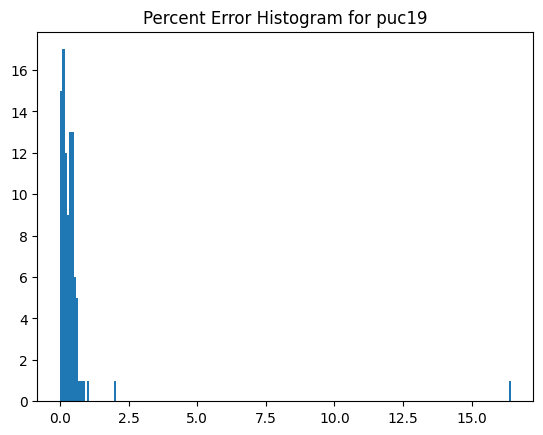

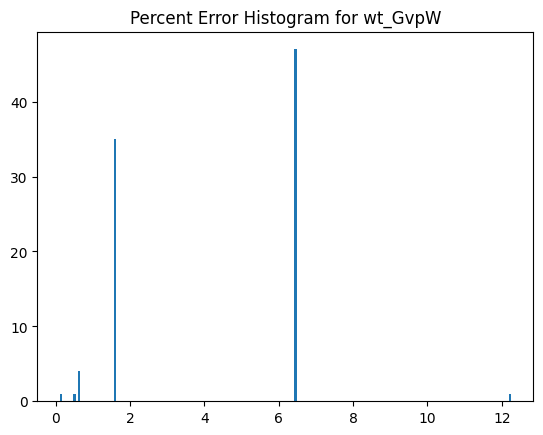

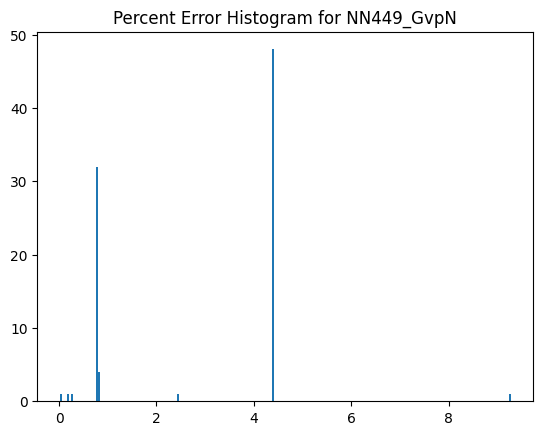

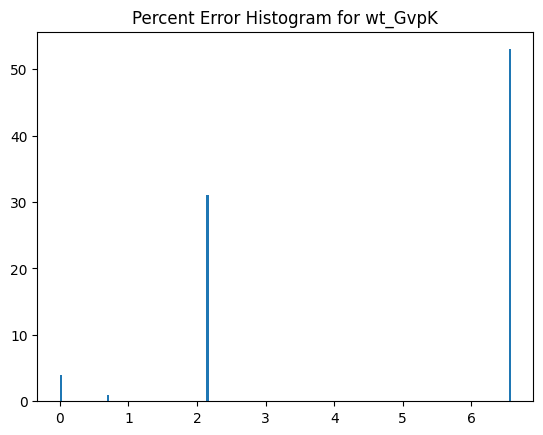

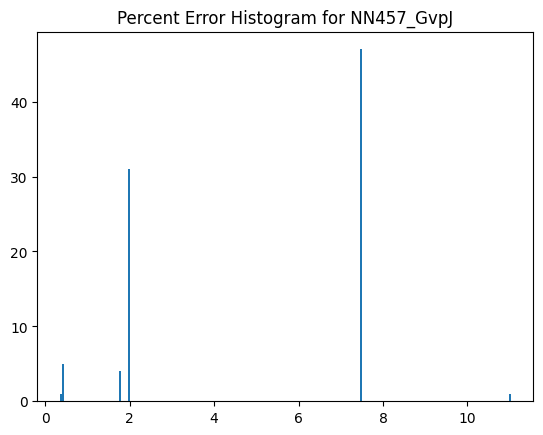

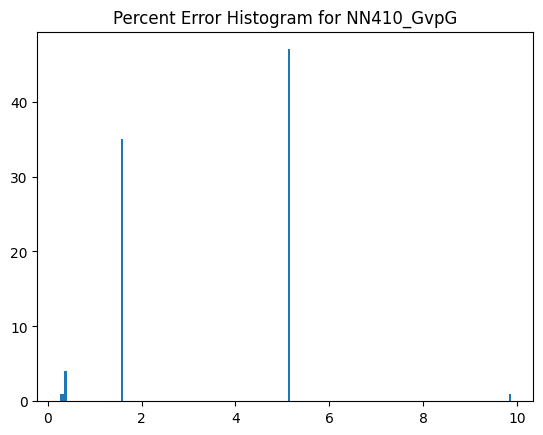

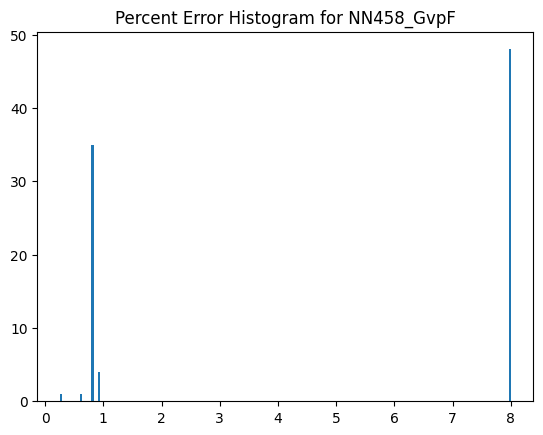

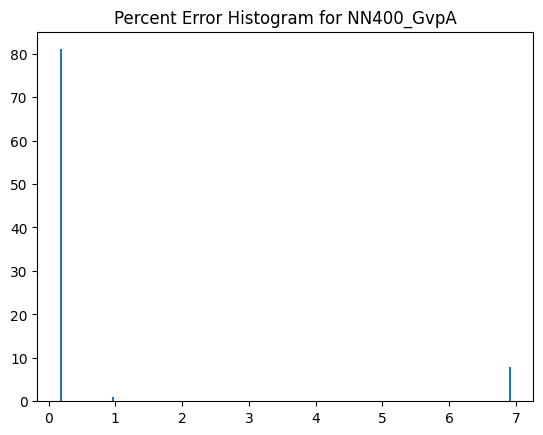

In [18]:
for comp in component_mapping.keys():
    comp_comparison_df = comparison_df[(comparison_df["Sample ID"] == component_mapping[comp][0])]
    display(comp_comparison_df[(comp_comparison_df["percent_error"] > 10)])
    plt.figure()

    plt.hist(comp_comparison_df['percent_error'], bins=200)
    plt.title(f"Percent Error Histogram for {component_mapping[comp][0]}")


# Check that all the source wells will not transfer more than 10 uL

In [19]:
echo_df = output_association.copy()
echo_df = echo_df[echo_df["Sample ID"] != "water"]
echo_df = echo_df[["Source Well", "Transfer Volume"]].groupby(["Source Well"]).sum().reset_index()
echo_df[echo_df["Transfer Volume"] > 10000]

,Source Well,Transfer Volume


In [20]:
echo_df

,Source Well,Transfer Volume
0,A11,10000
1,A13,10000
2,A15,10000
3,A17,10000
4,A3,10000
5,A5,10000
6,A7,10000
7,A9,10000
8,B15,10000
9,B17,10000
